## What is Text Splitting?

Suppose you have a very large document:

A 1000-page PDF containing millions of words.

You generally don't want to treat the entire PDF as one giant piece of text. So we divide it into smaller pieces called chunks.

In [ ]:
# 1000-page PDF
#        ↓
#    Text Splitting
#        ↓
#  ┌─────────┐
#  │ Chunk 1 │ → pages 1–5
#  ├─────────┤
#  │ Chunk 2 │ → pages 6–10
#  ├─────────┤
#  │ Chunk 3 │ → pages 11–15
#  ├─────────┤
#  │   ...   │
#  └─────────┘

Text splitting = breaking a large text/document into smaller manageable pieces called chunks.

The component that performs this operation is called a text splitter or text splitters.

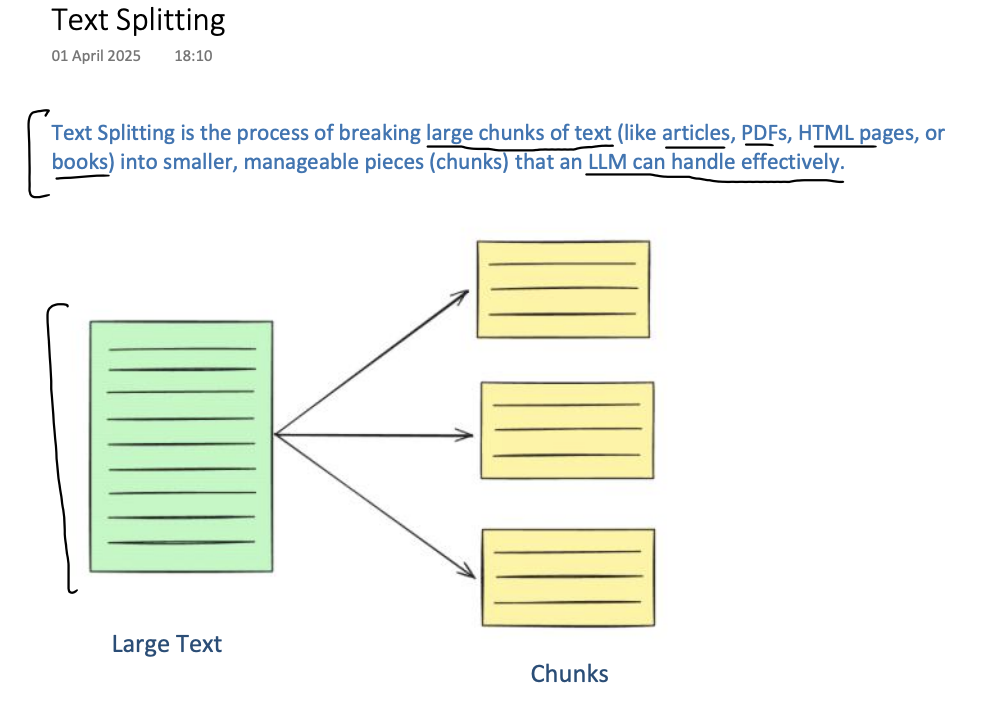

# Q Why can't we simply give the whole PDF to an LLM?

This is where context length becomes important. Every LLM has a maximum amount of information it can process in a single request. This maximum is called the context window/context length.

For example, imagine an LLM has: Context length = 50,000 tokens And your PDF contains 100,000 tokens

You cannot simply do: PDF → LLM because 100,000 tokens > 50,000 token limit

In [1]:
# Large PDF
#    ↓
# Text Splitting
#    ↓
# Chunk 1
# Chunk 2
# Chunk 3
# ...
# Chunk N
#    ↓
# Process chunks

## We send LLM chunk by chunk instead of sending the whole pdf

a Token is minimum unit in LLM that it processes. It is not necessarily equal to one word. tokenization depends on the tokenizer. A token can represent a whole word, part of a word, punctuation, etc.

# Q Why not make every chunk exactly one page?

You can, but it is usually not the best strategy.

Your notes give:

- Chunk 1 → Page 1
- Chunk 2 → Page 2
- Chunk 3 → Page 3

This is one possible strategy, but imagine a paragraph starts at the bottom of page 1 and continues on page 2.

You could end up with:

Chunk 1: "The main reason for using transformers is..."


Chunk 2: "...their ability to model long-range dependencies."

The meaning has been split across two chunks.

That's why modern text splitting usually tries to split according to meaningful boundaries such as:

In [ ]:
# Document
#    ↓
# Sections
#    ↓
# Paragraphs
#    ↓
# Sentences
#    ↓
# Words

# Q What is the goal of chunking ?

The goal isn't simply:

"Make small pieces."

The real goal is:

Create chunks that are small enough to process efficiently but large enough to preserve meaningful context.

# Chunk Size

A text splitter usually has something like: chunk_size = 500

This means approximately:

Create chunks containing around 500 units according to the splitter's length function—often characters or tokens, depending on the splitter/configuration.

For example, conceptually:

Large document -> 500 units -> Chunk 1


500 units -> Chunk 2

500 units -> Chunk 3

The exact behavior depends on the splitter.

## Chunk Overlap

Suppose we have:

Chunk 1:
A B C D E F G H I J


Chunk 2:
K L M N O P Q R S T

There is no overlap.

But suppose the meaning around the boundary is important.

We can use:

chunk_size = 10 and chunk_overlap = 3

Then:

Chunk 1:
A B C D E F G H I J


Chunk 2:
H I J K L M N O P Q


Chunk 3:
O P Q R S T U V W X

The overlapping part is: H I J

and then: O P Q

Note : Smaller, semantically coherent chunks generally produce more focused embeddings.

## Q Why is text splitting important ?

***1. Model Limitations:***


A large document may exceed the model's context window. Many embedding models and language models have maximum input size constraint.

For example:

Document = 200,000 tokens

LLM context = 50,000 tokens

We split:

200k tokens -> Chunk 1 = 5k ,Chunk 2 = 5k, Chunk 3 = 5k ...

Now each individual chunk can be processed.

***2. Downstream Tasks:***

Team splitting improves nearly every LLM powered tasks

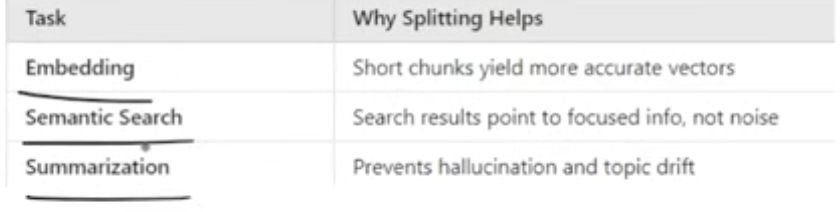

Text splitting affects:

- Embeddings
- Semantic search
- Retrieval
- Question answering
- Summarization
- RAG
- Document classification
- Information extraction

# Q Why does chunking improve semantic search?

Imagine one huge document contains Information about:
- Virat Kohli
- MS Dhoni
- Rohit Sharma
- Sachin Tendulka 
- Indian cricket
- IPL
- World Cup

If you create one embedding for the entire document, that vector represents many different topics.

Now query: "Which team does Virat Kohli play for?"

The embedding represents a huge mixture of information.

Instead, split:

Chunk 1 → Virat Kohli

Chunk 2 → MS Dhoni

Chunk 3 → Rohit Sharma

Chunk 4 → Sachin Tendulkar

Then:

Chunk 1 → Embedding 1

Chunk 2 → Embedding 2

Chunk 3 → Embedding 3

Chunk 4 → Embedding 4

Chunking can make retrieval more focused because each embedding represents a more coherent piece of information.

# What does "search results point to focused information, not noise" mean?

Suppose Chunk A contains:

The company was founded in 1985.

The CEO is...

The company operates in...

The annual leave policy allows 25 days.

The company has offices in...

The revenue was...

The embedding represents many unrelated concepts. But if we have:

Chunk A: Annual leave policy allows employees 25 days of paid leave...

then a query: "How many annual leave days do employees get?"

has a much stronger semantic relationship with Chunk A.

In [ ]:
# So:

# Better chunks
#      ↓
# Better embeddings
#      ↓
# Better retrieval
#      ↓
# Better context for LLM
#      ↓
# Better answer

Suppose you have a huge document containing:

- Topic A
- Topic B
- Topic C
- Topic D
- Topic E

If you ask an LLM to summarize everything at once, it may struggle with:

1. context limits
2. too many topics
3. information prioritization
4. maintaining structure

Instead, we can use a hierarchical approach:

In [ ]:
# Large document
#        ↓
# Split into chunks
#        ↓
# Summarize each chunk
#        ↓
# Chunk summaries
#        ↓
# Combine/refine summaries
#        ↓
# Final summary

In [2]:
# For example:

# Chunk 1 → Summary 1
# Chunk 2 → Summary 2
# Chunk 3 → Summary 3
# Chunk 4 → Summary 4

# Then:
# Summary 1
# Summary 2
# Summary 3
# Summary 4
#      ↓
#     LLM
#      ↓
# Final Summary

# This is one way to handle documents that are too large for a single context window.

# Important:

# Chunking doesn't guarantee that hallucinations disappear.

# It can reduce some sources of confusion and improve grounding, but an LLM can still hallucinate

***3. Optimizing Computational Resources:***

Working with smaller chunks of texts can be more memory efficient and allow for better parallelization of processing tasks

This makes sense.

Imagine processing:

100 MB document

as one enormous operation versus:

1000 × 100 KB chunks

The smaller pieces can often be processed independently.

For example:

Chunk 1 ──→ Worker 1

Chunk 2 ──→ Worker 2

Chunk 3 ──→ Worker 3

Chunk 4 ──→ Worker 4

This allows parallel processing.

"Why do we need text splitting?"

A strong answer is:

Text splitting is used to divide large documents into smaller, semantically meaningful chunks that can fit within model context limits and can be processed efficiently. In RAG systems, chunking also improves embedding quality and retrieval precision because each embedding represents a more focused piece of information.

And if they ask:

"Why not embed the entire document?"

Say:

A single embedding for a very large document can represent many unrelated topics and therefore provide poor retrieval granularity. By creating embeddings for smaller, coherent chunks, semantic search can retrieve the specific information relevant to a user's query.

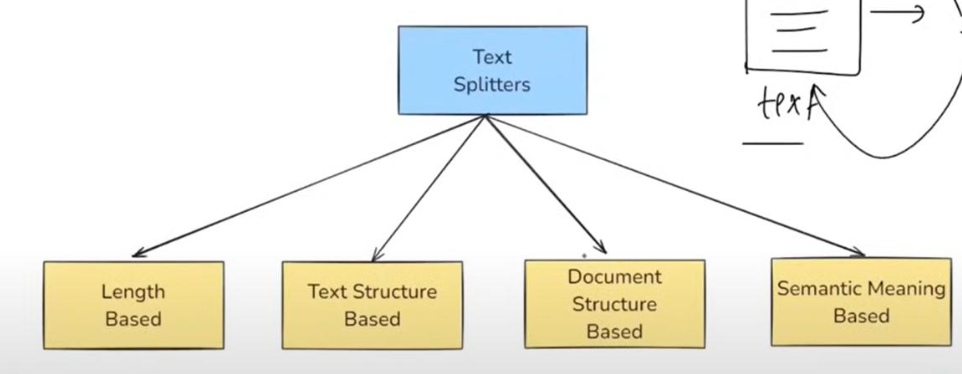

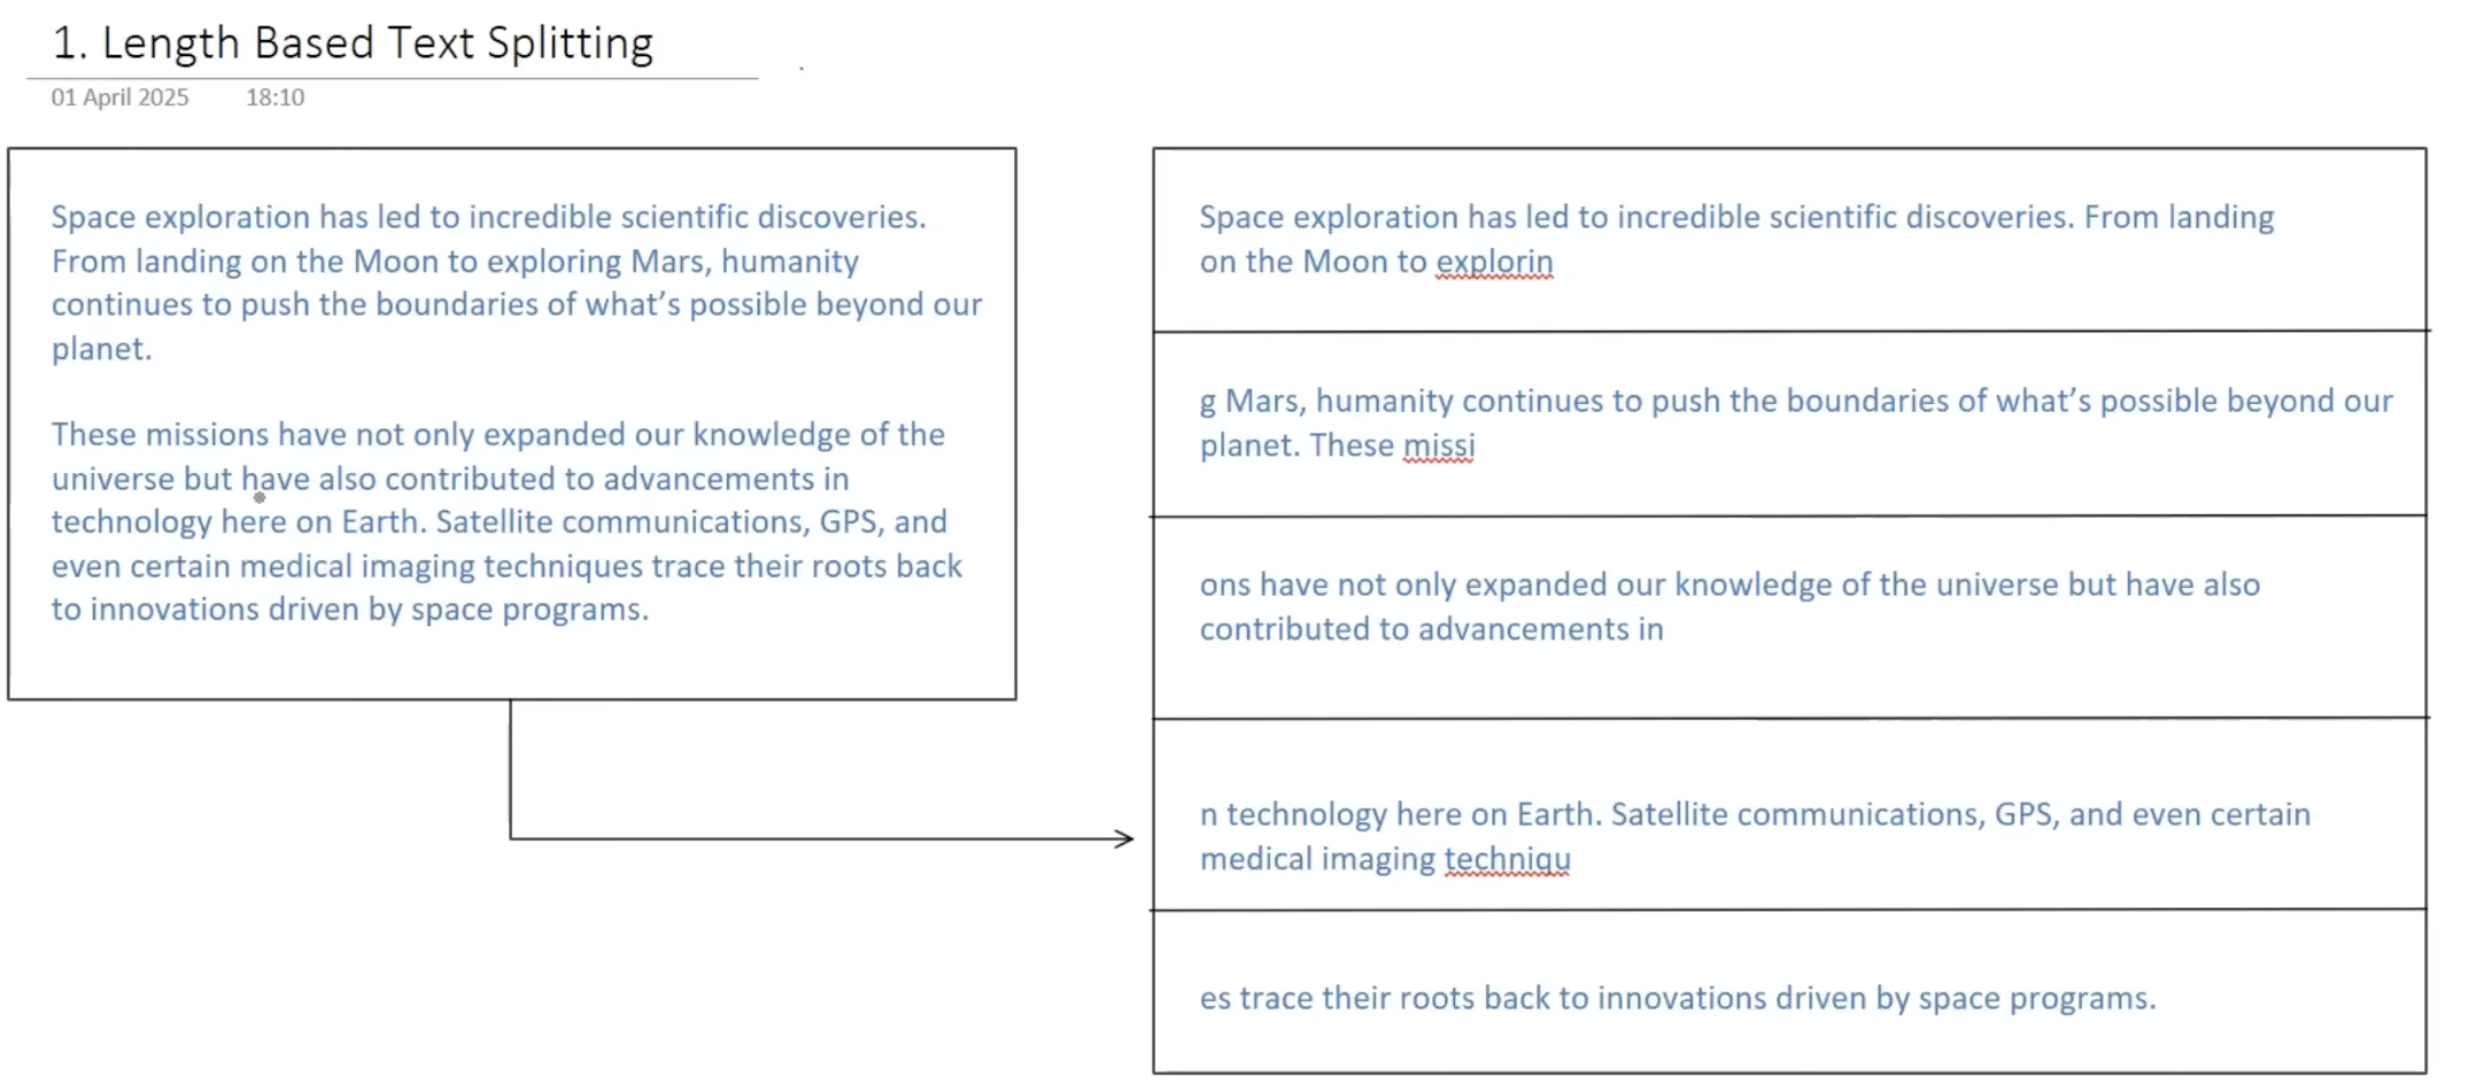

Choose a maximum chunk size and split the text based on that size.

Before splitting, we decide: Chunk size

For example: chunk_size = 100 characters

This means we want each chunk to contain approximately 100 characters.

The size can be measured using different units:

- characters
- tokens
- words etc.

Your notes specifically focus on characters.


Chunk 1 → first ~100 characters

Chunk 2 → next ~100 characters

Chunk 3 → next ~100 characters

Chunk 4 → next ~100 characters

Chunk 5 → remaining characters

It doesn't initially care about:

whether a sentence has finished,

whether a paragraph has finished,

whether the idea is complete.

In [ ]:
# We predecide the size of the chunk

## you can decide the size of chunk in characters as well as in tokens too

This is simply a visualization tool that lets you experiment with different text-splitting strategies.

You can provide your text and change:

- Splitter
- Chunk Size
- Chunk Overlap

and see:

- Total Characters
- Number of Chunks
- Average Chunk Size

This helps you visually understand how different chunk sizes affect splitting.

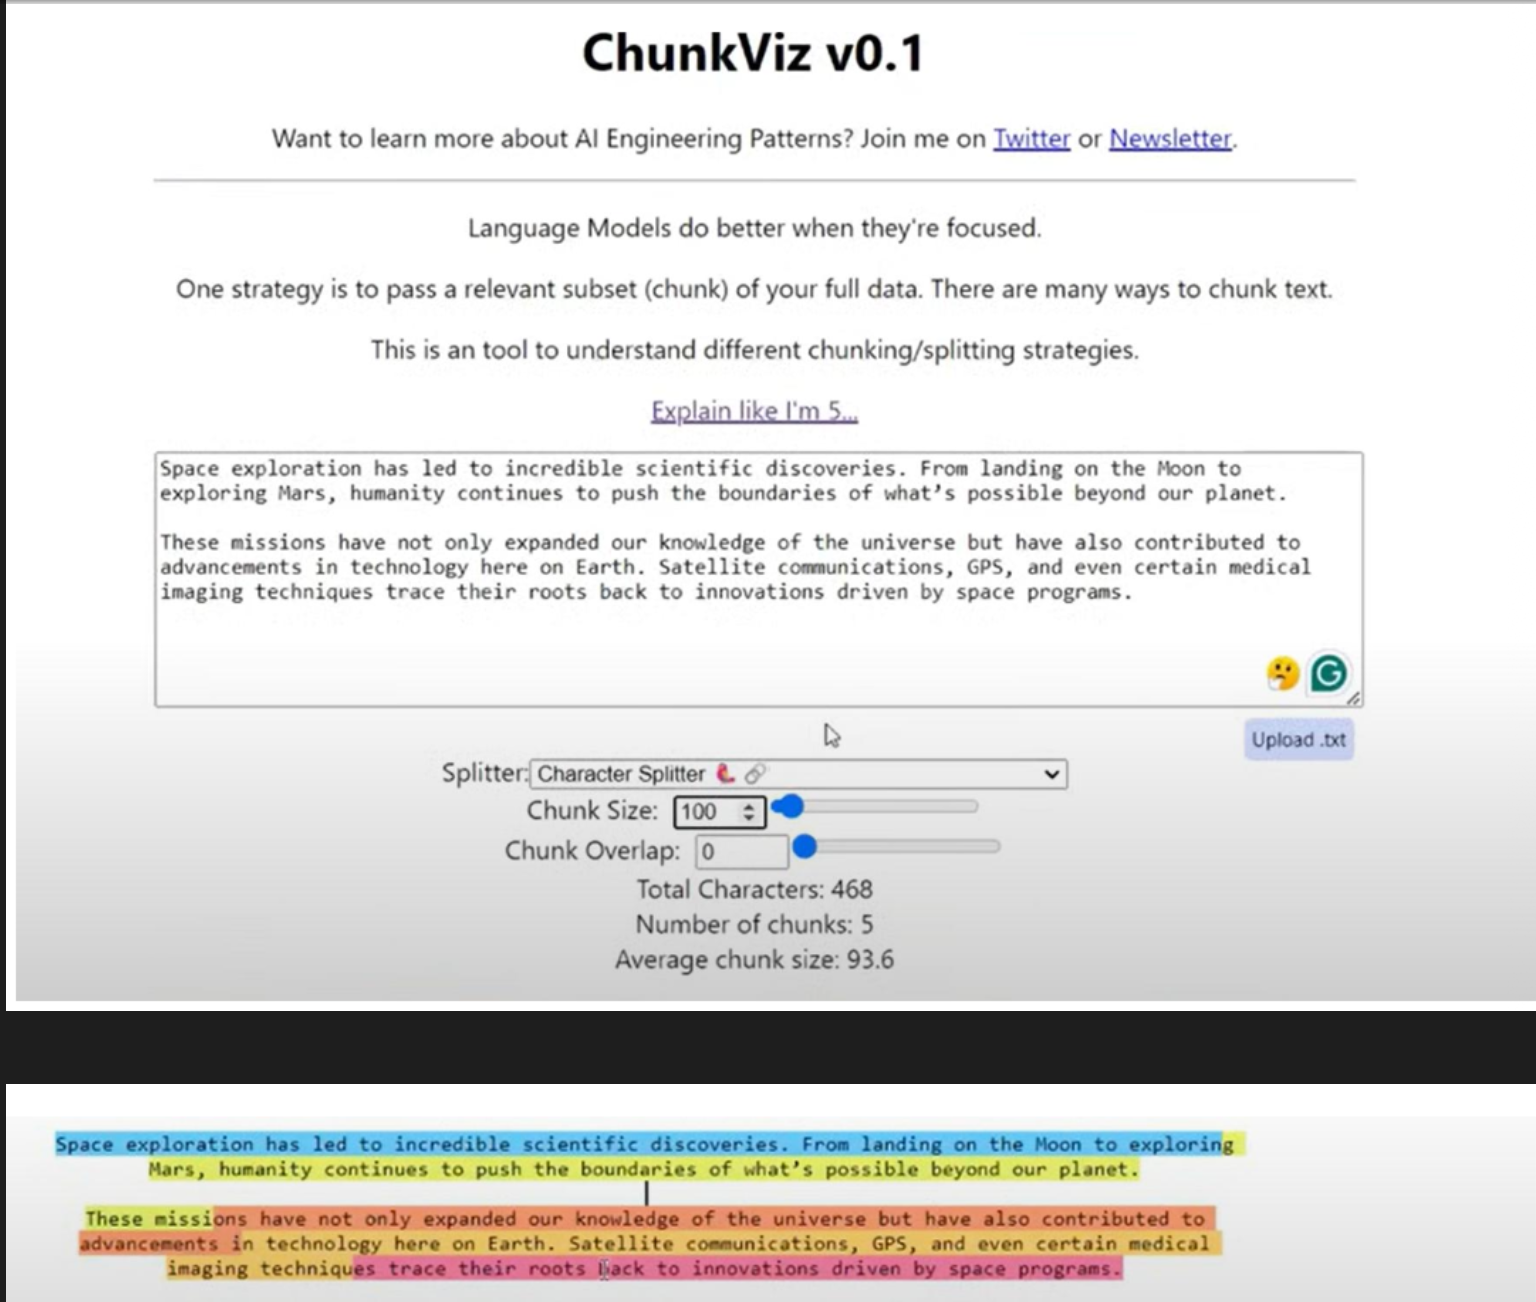

Chunk size Increase -> Lesser no of chunks 

Chunk Overlap increase -> Greater no of chunks

# Advantages:

- Very fast 
- Easy to implement 
- Very simple to understand 

# Disadvantages:

- Doesn't see grammar or meaning of the chunk
- a word can get divided between two chunks

In [5]:
!pip install langchain-text-splitters

In [ ]:
## in splitter you always mention chunk_size, chunk_overlap and separator

In [10]:
from langchain_text_splitters import CharacterTextSplitter

text='''
What is Pokémon?
Pokémon (short for Pocket Monsters) is a globally renowned media franchise centered on fictional creatures with unique powers, abilities, and designs. Created by Satoshi Tajiri and Ken Sugimori, the franchise debuted in 1996 with the release of the Pokémon Red and Blue video games for the Nintendo Game Boy.

Today, Pokémon spans video games, trading card games (TCG), animated television series, movies, merchandise, and competitive esports, making it one of the highest-grossing media franchises of all time.

Core Concept and Gameplay
The central premise of the Pokémon universe revolves around humans—known as Pokémon Trainers—who catch, train, and battle creatures called Pokémon.

The Goal: Trainers typically aim to catch a wide variety of species to complete the Pokédex (an electronic encyclopedia) and train a team of Pokémon to battle other trainers, ultimately striving to become a Pokémon Champion.

Turn-Based Combat: Battles are strategic and turn-based. Pokémon use up to four moves in battle, spanning various types (such as Water, Fire, Grass, Electric, Psychic, and Dragon).

The Type Advantage System: Combat heavily relies on elemental matchups. For example, Water-type moves are super-effective against Fire-type Pokémon, but less effective against Grass-type Pokémon.

Key Elements of the Franchise
1. Pokémon Evolution
Many Pokémon can evolve into new, more powerful species when they reach a specific level, are exposed to special items (like stones), experience friendship milestones, or meet other unique conditions. Evolution typically alters a Pokémon's appearance, stats, and typing.

2. Types
There are currently 18 distinct elemental types in the Pokémon universe. Every Pokémon and move possesses one or two types, which dictate their strengths and weaknesses:

Normal, Fire, Water, Grass, Electric, Ice

Fighting, Poison, Ground, Flying, Psychic, Bug

Rock, Ghost, Dragon, Dark, Steel, Fairy

3. Legendary and Mythical Pokémon
Beyond standard wild Pokémon, the universe features rare, immensely powerful creatures known as Legendary and Mythical Pokémon. These creatures often play crucial roles in the lore and mythology of the various regions and are typically difficult to find or capture.

Major Media Pillars
Video Games: Divided into "generations," the core RPG series introduces new regions, characters, and hundreds of new Pokémon species with every major installment.

Trading Card Game (TCG): A massive competitive and collecting hobby where players build decks of cards featuring Pokémon, Trainers, and Energy to defeat opponents.

Anime Series: Follows various protagonists—most famously Ash Ketchum through his multi-decade journey, followed by newer heroes like Liko and Roy—as they travel the world, make friends, and battle gym leaders.

Competitive Esports (VGC & TCG): Global circuits where players compete at regional, international, and world championship levels for prestigious titles and prizes.
'''

splitter=CharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=0,
    separator='' ## no separator is used here
)

## to split the text we use splitter.split_text()

result=splitter.split_text(text=text)

print(result)

['What is Pokémon?\nPokémon (short for Pocket Monsters) is a globally renowned media franchise centere', 'd on fictional creatures with unique powers, abilities, and designs. Created by Satoshi Tajiri and K', 'en Sugimori, the franchise debuted in 1996 with the release of the Pokémon Red and Blue video games', 'for the Nintendo Game Boy.\n\nToday, Pokémon spans video games, trading card games (TCG), animated tel', 'evision series, movies, merchandise, and competitive esports, making it one of the highest-grossing', 'media franchises of all time.\n\nCore Concept and Gameplay\nThe central premise of the Pokémon universe', 'revolves around humans—known as Pokémon Trainers—who catch, train, and battle creatures called Poké', 'mon.\n\nThe Goal: Trainers typically aim to catch a wide variety of species to complete the Pokédex (a', 'n electronic encyclopedia) and train a team of Pokémon to battle other trainers, ultimately striving', 'to become a Pokémon Champion.\n\nTurn-Based Combat: Battle

In [12]:
len(result)

30

In [13]:
result[0]

'What is Pokémon?\nPokémon (short for Pocket Monsters) is a globally renowned media franchise centere'

## We will connect document loader and text splitter

In [14]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import CharacterTextSplitter


loader=PyPDFLoader(file_path='/Users/priyanshugupta/Desktop/Generative AI/sample-5-page-pdf-a4-size.pdf')

docs=loader.load()

splitter=CharacterTextSplitter(chunk_size=100,chunk_overlap=3,separator='')

results=splitter.split_documents(docs)
print(results)

[Document(metadata={'producer': 'Canva', 'creator': 'Canva', 'creationdate': '2024-07-07T12:07:05+00:00', 'title': 'Sample 5-Page PDF A4 Size | Sample-Files.com', 'moddate': '2024-07-07T12:07:04+00:00', 'keywords': 'DAGKRGfiZEo,BAEVm-WErFA', 'author': 'Jericho', 'source': '/Users/priyanshugupta/Desktop/Generative AI/sample-5-page-pdf-a4-size.pdf', 'total_pages': 5, 'page': 0, 'page_label': '1'}, page_content='Innovative Tech\nSolutions, Inc.\nProduct Launch Report:\nSmartHome Hub\nPrepared by:\nAlex Johnson\nsampl'), Document(metadata={'producer': 'Canva', 'creator': 'Canva', 'creationdate': '2024-07-07T12:07:05+00:00', 'title': 'Sample 5-Page PDF A4 Size | Sample-Files.com', 'moddate': '2024-07-07T12:07:04+00:00', 'keywords': 'DAGKRGfiZEo,BAEVm-WErFA', 'author': 'Jericho', 'source': '/Users/priyanshugupta/Desktop/Generative AI/sample-5-page-pdf-a4-size.pdf', 'total_pages': 5, 'page': 0, 'page_label': '1'}, page_content='mple-files.com\n+1-555-123-4567'), Document(metadata={'producer':

In [15]:
len(results)

21

In [16]:
results[0]

Document(metadata={'producer': 'Canva', 'creator': 'Canva', 'creationdate': '2024-07-07T12:07:05+00:00', 'title': 'Sample 5-Page PDF A4 Size | Sample-Files.com', 'moddate': '2024-07-07T12:07:04+00:00', 'keywords': 'DAGKRGfiZEo,BAEVm-WErFA', 'author': 'Jericho', 'source': '/Users/priyanshugupta/Desktop/Generative AI/sample-5-page-pdf-a4-size.pdf', 'total_pages': 5, 'page': 0, 'page_label': '1'}, page_content='Innovative Tech\nSolutions, Inc.\nProduct Launch Report:\nSmartHome Hub\nPrepared by:\nAlex Johnson\nsampl')

In [23]:
results[1]

Document(metadata={'producer': 'Canva', 'creator': 'Canva', 'creationdate': '2024-07-07T12:07:05+00:00', 'title': 'Sample 5-Page PDF A4 Size | Sample-Files.com', 'moddate': '2024-07-07T12:07:04+00:00', 'keywords': 'DAGKRGfiZEo,BAEVm-WErFA', 'author': 'Jericho', 'source': '/Users/priyanshugupta/Desktop/Generative AI/sample-5-page-pdf-a4-size.pdf', 'total_pages': 5, 'page': 0, 'page_label': '1'}, page_content='mple-files.com\n+1-555-123-4567')

## Text-Structure Based (Recursive Character Text Splitter)

Assumes there is hierarchy of structure: Section -> Paragraph -> sentence -> word -> character

Recursive Character Text Splitter, which is much smarter than the basic CharacterTextSplitter you were studying before.

Idea: Don't immediately cut the text at a fixed character count. First try to split at meaningful boundaries—paragraphs, then lines/sentences, then words, and only finally characters.

## Why we need it ?


Previously, you saw length-based splitting.

For example: chunk_size = 100 , The basic idea was

Original text -> Take 100 characters -> Chunk 1 -> Take next 100 characters -> Chunk 2 -> ...

The problem is that it doesn't understand the structure of language.

It might produce: "Artificial intellige"

and then: "nce is useful..."

So a word can be broken in half. Even worse, it can break a sentence or an idea in the middle.

Recursive splitting tries to avoid this.

# What does recursive mean here ?

If the current splitting method cannot produce chunks of the desired size, try another, finer-grained splitting method.

Think of it like a hierarchy: 

Paragraph -> sentence / line -> words -> characters

So the splitter says: "First, can I divide this text using paragraphs?"

If that doesn't give chunks small enough: "Okay, let's split those large pieces into smaller sentences/lines."

Still too large? "Okay, let's split into words."

Still too large? "Finally, split into individual characters."

That's the entire concept.

## Separate hierarchy implementation

1. \n\n
2. \n
3. " "
4. ""

\n\n: Two newline characters. Usually represents a paragraph boundary. So a paragraph separator

\n: One newline character. Usually represents a line boundary. Line separator

" ": A space. Word separator. 

"": Empty String. If nothing else works, split at the character level.

Paragraph→Line/Sentence→Word→Character
	​




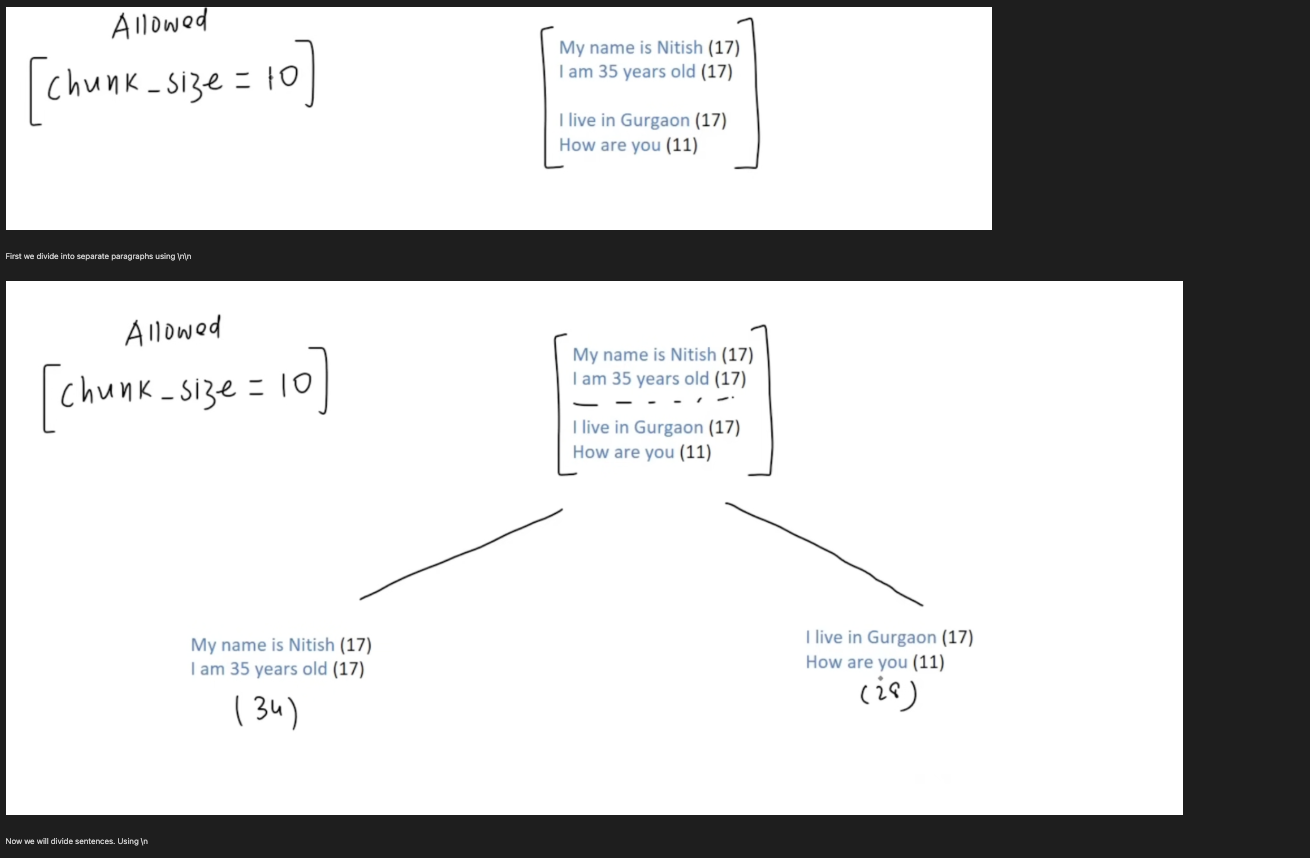

Now we will divide sentences. Using \n

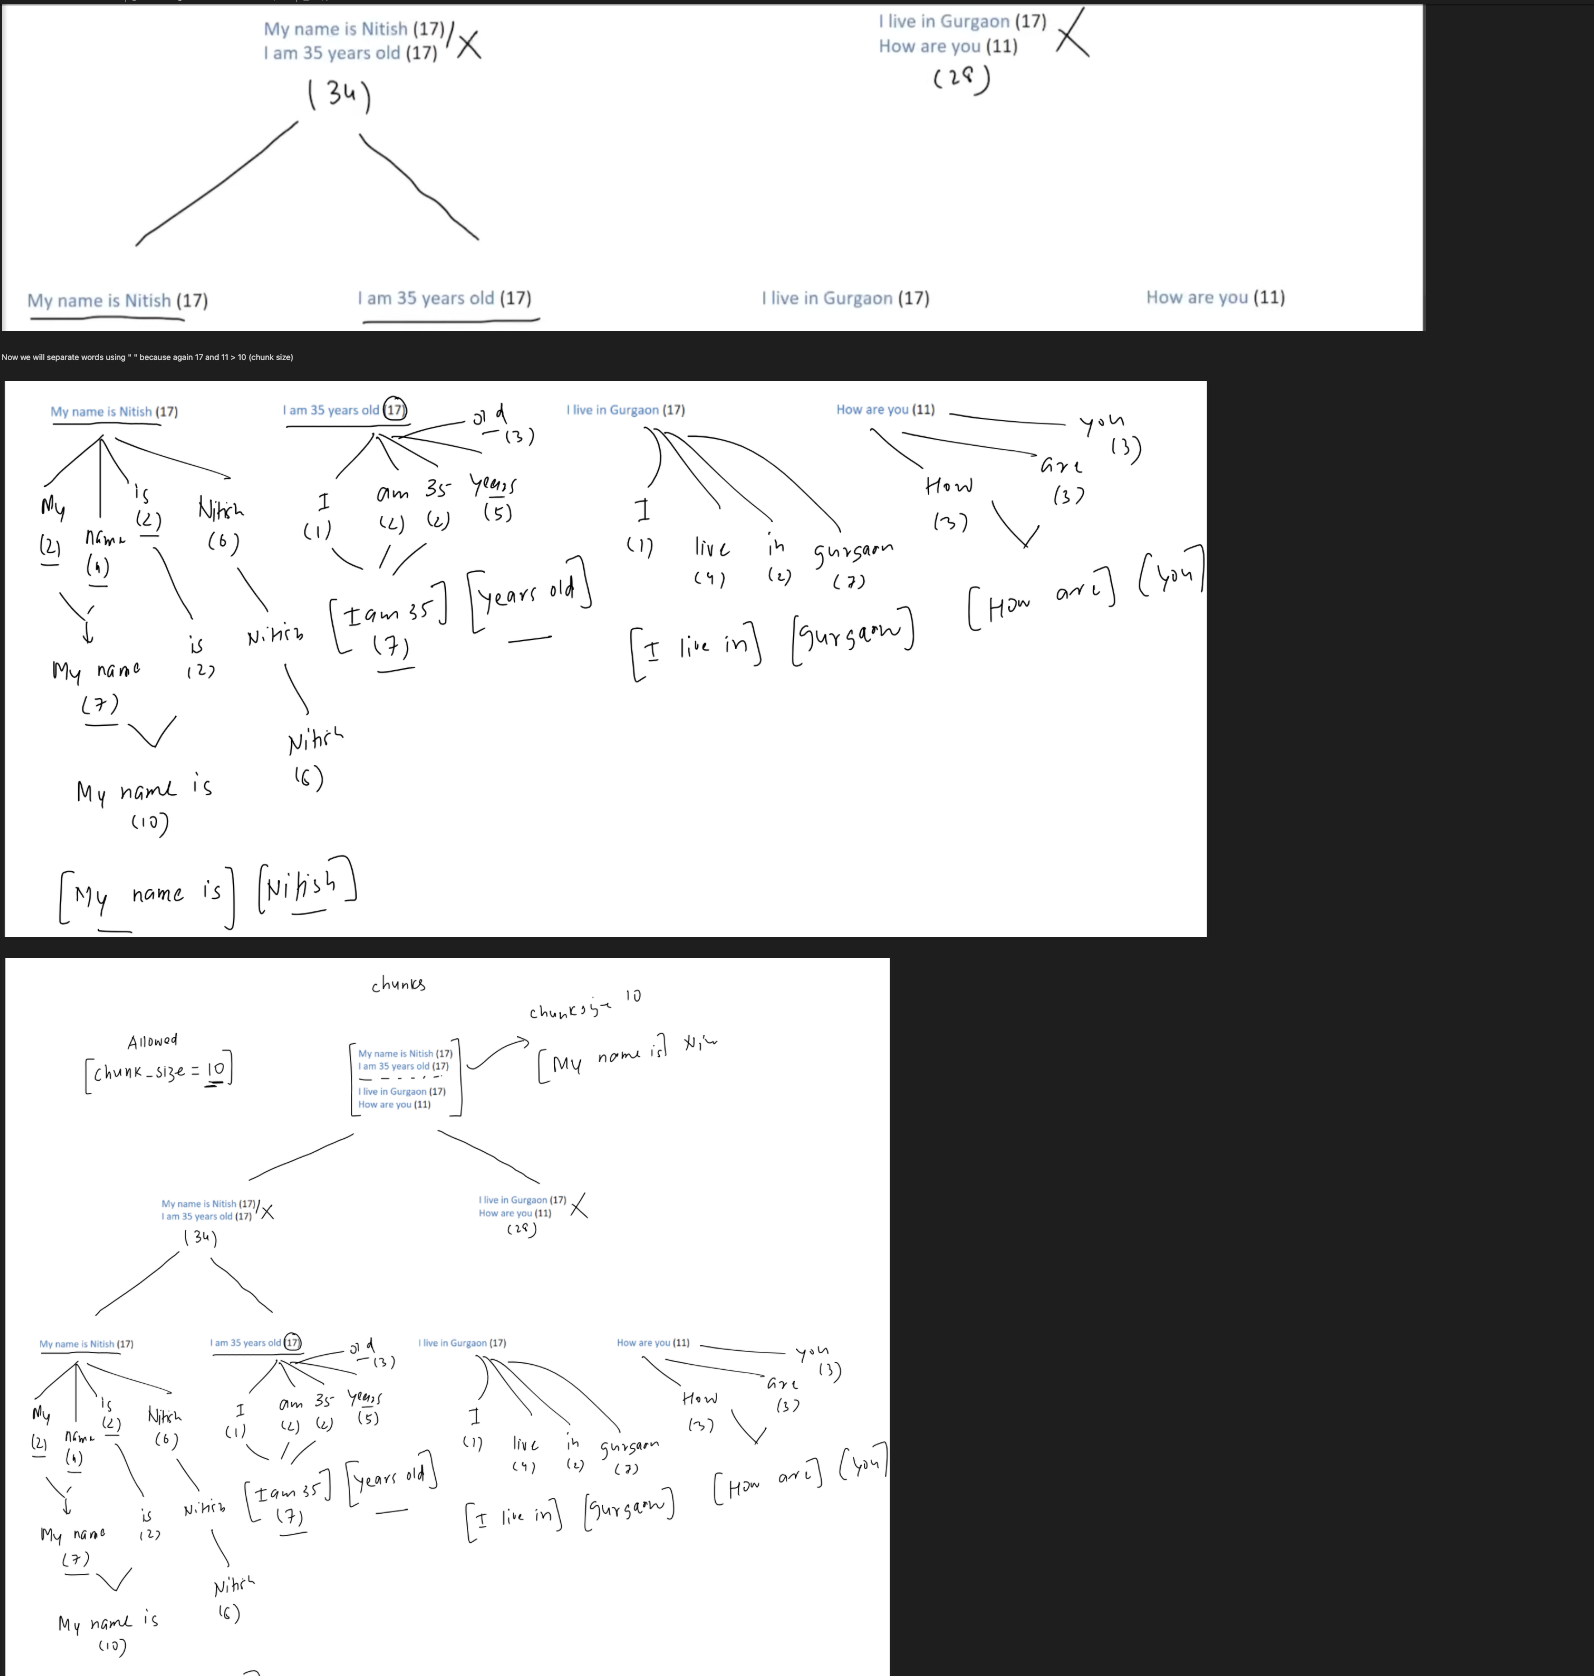

In [ ]:
    #                 Document
    #                    │
    #                    ▼
    #             Try "\n\n"
    #           (paragraphs)
    #                    │
    #       ┌────────────┴────────────┐
    #       │                         │
    # Size <= 100                Size > 100
    #       │                         │
    #       ▼                         ▼
    #    Keep it                Try "\n"
    #                                 │
    #                       ┌─────────┴─────────┐
    #                       │                   │
    #                 Size <= 100          Size > 100
    #                       │                   │
    #                       ▼                   ▼
    #                    Keep it            Try " "
    #                                           │
    #                                 ┌─────────┴─────────┐
    #                                 │                   │
    #                           Size <= 100          Size > 100
    #                                 │                   │
    #                                 ▼                   ▼
    #                              Keep it            Try ""
    #                                                    │
    #                                                    ▼
    #                                             Character split

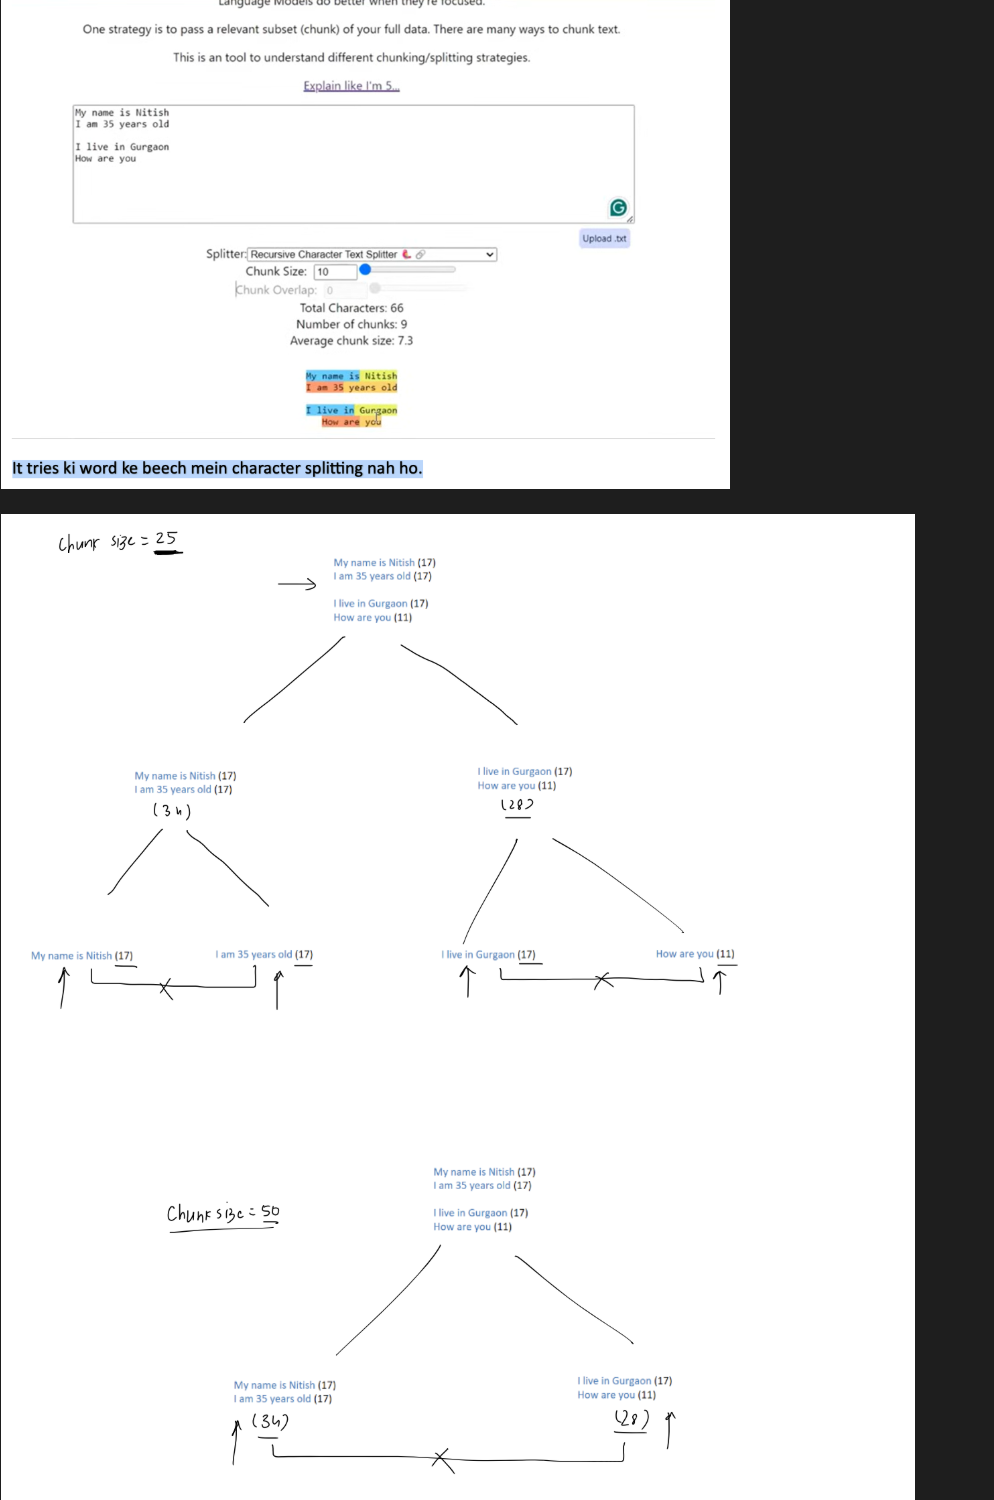

In 1st case algo tries to merge two sentences again but 17+17=34 > 25 .. Therefor it won't be able to merge them .



In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter=RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=0)

 
result=splitter.split_text(text)
print(result)

['What is Pokémon?', 'Pokémon (short for Pocket Monsters) is a globally renowned media franchise centered on fictional creatures with unique powers, abilities, and designs. Created by Satoshi Tajiri and Ken Sugimori, the franchise debuted in 1996 with the release of the Pokémon Red and Blue video games for the Nintendo', 'Game Boy.', 'Today, Pokémon spans video games, trading card games (TCG), animated television series, movies, merchandise, and competitive esports, making it one of the highest-grossing media franchises of all time.', 'Core Concept and Gameplay\nThe central premise of the Pokémon universe revolves around humans—known as Pokémon Trainers—who catch, train, and battle creatures called Pokémon.', 'The Goal: Trainers typically aim to catch a wide variety of species to complete the Pokédex (an electronic encyclopedia) and train a team of Pokémon to battle other trainers, ultimately striving to become a Pokémon Champion.', 'Turn-Based Combat: Battles are strategic and turn-ba

In [25]:
len(result)

18

In [28]:
print(result[0])
print(result[17])
print(result[10])

What is Pokémon?
Competitive Esports (VGC & TCG): Global circuits where players compete at regional, international, and world championship levels for prestigious titles and prizes.
2. Types
There are currently 18 distinct elemental types in the Pokémon universe. Every Pokémon and move possesses one or two types, which dictate their strengths and weaknesses:

Normal, Fire, Water, Grass, Electric, Ice

Fighting, Poison, Ground, Flying, Psychic, Bug


## Document based Text Splitter

We know text -> para -> sentences -> words -> characters

but what if the document is not written in english format:

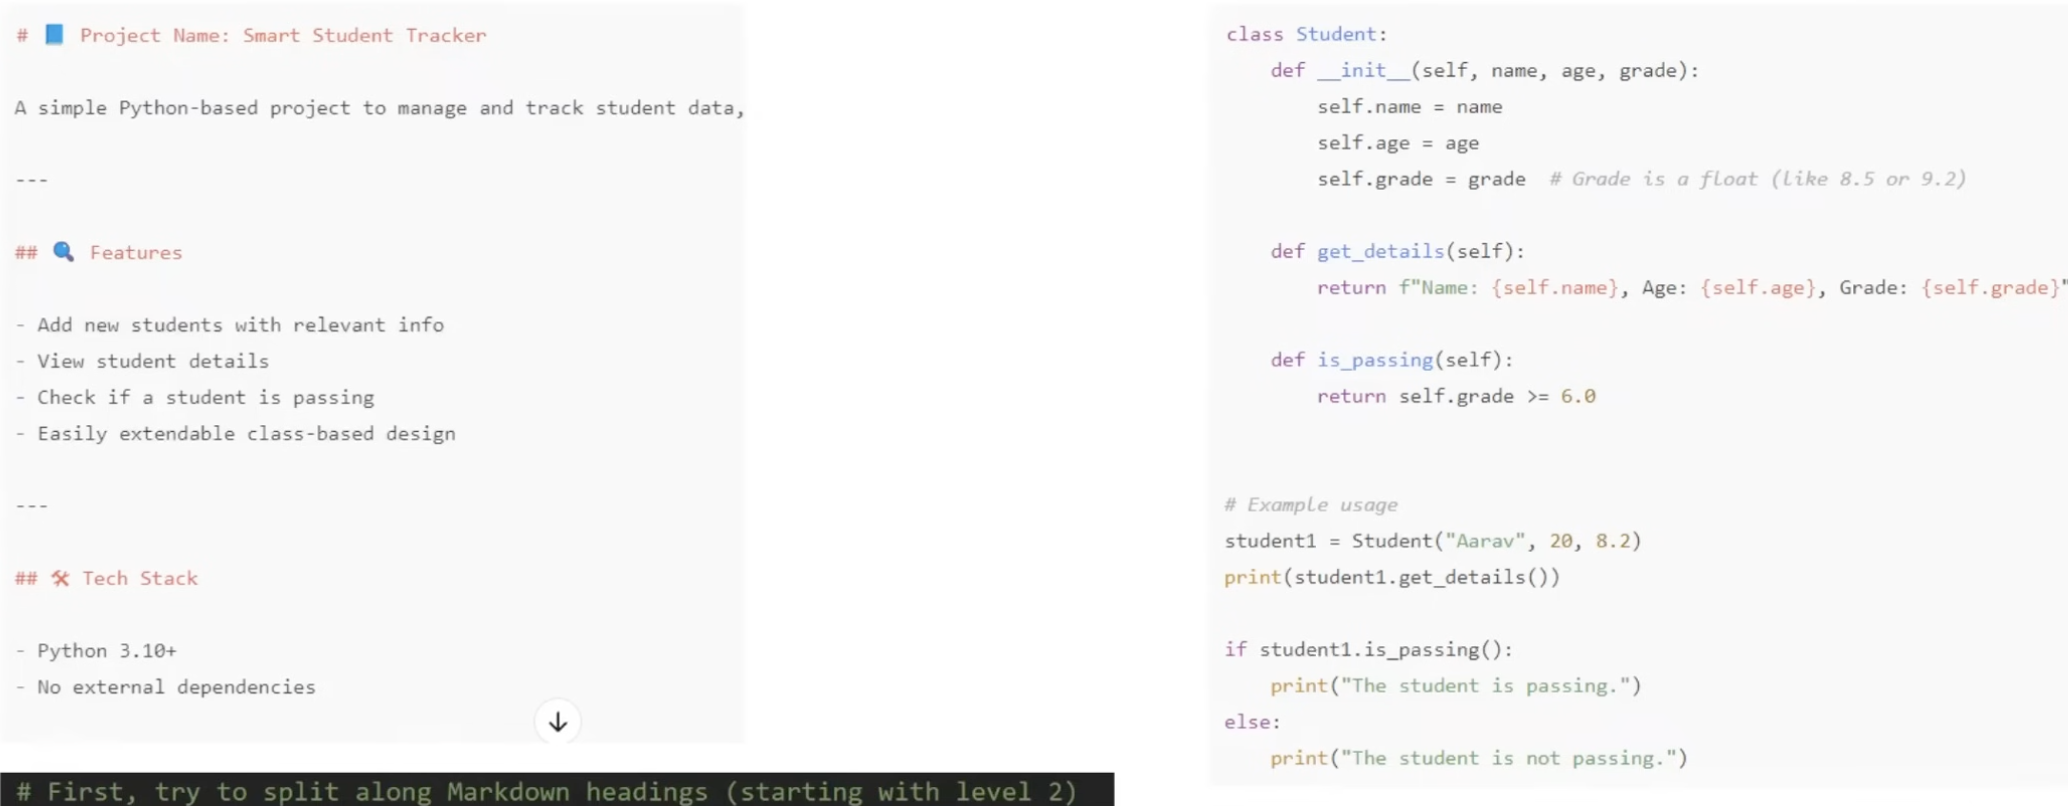

1st one is markdown text and 2nd one is python code.

Python code can’t split this as normal text. Instead, we organize it based on specific keywords such as classes, functions, and loops.

The same approach we learned for plain text can also be applied to other types of documents. Here, we use a Recursive Character Text Splitter as well, but the separators we use are different depending on the document type.

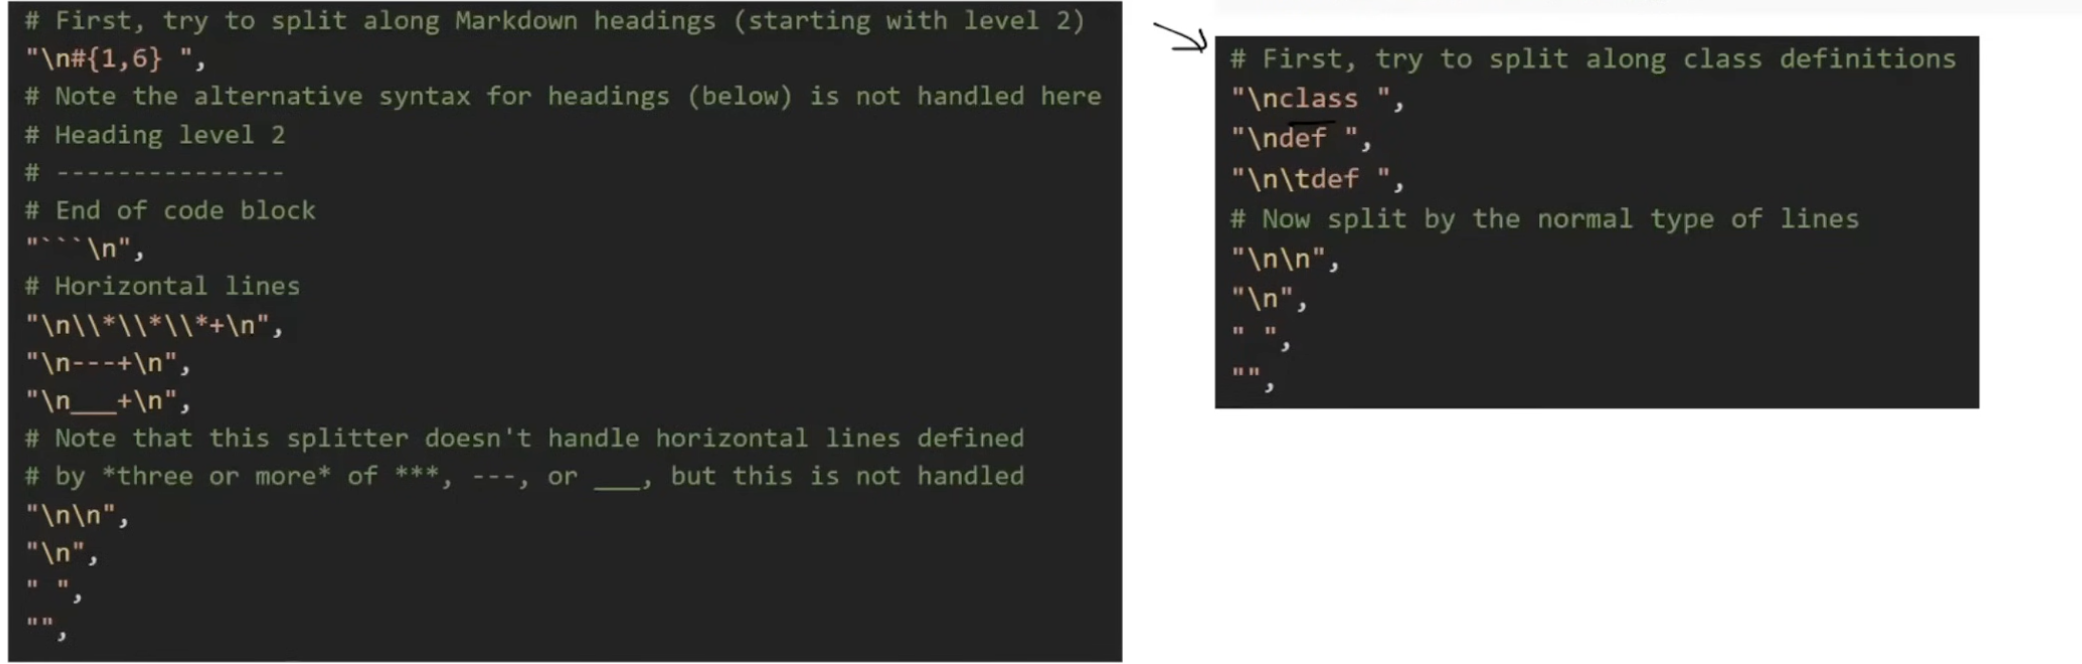

1st is for markdown text and 2nd one is for python code

Document based Text splitting is extension of Recursive character text splitter.

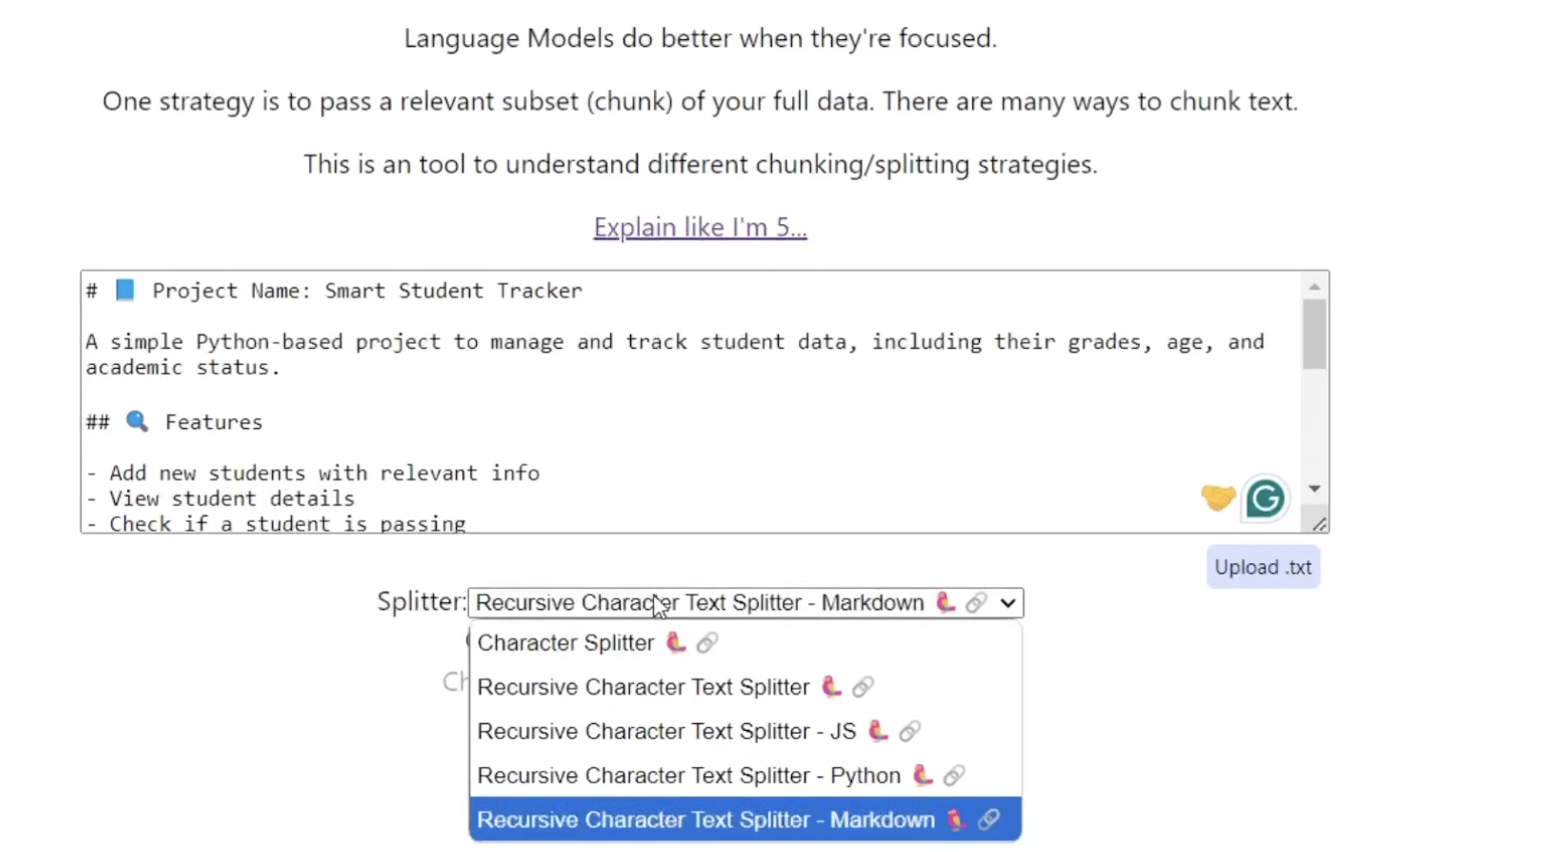

In [33]:
from langchain_text_splitters import RecursiveCharacterTextSplitter,Language

text=""" 

class Student:
    def __init__(self,name,age,grade):
        self.name=name
        self.age=age
        self.grade=grade
    
    def get_details(self):
        return self.name
    
    def is_passing(self):
        return self.grade >=6.0

## Example Usage
student1=Student("Aarav", 20, 8.2)
print(student1.get_details())


if (student1.is_passing()):
    print("student is passing")
else:
    print("student failed")
"""

## Initalize the splitter

splitter=RecursiveCharacterTextSplitter(Language.PYTHON,chunk_size=300, chunk_overlap=0)

result=splitter.split_text(text)

print(result)


['class Student:\n    def __init__(self,name,age,grade):\n        self.name=name\n        self.age=age\n        self.grade=grade\n\n    def get_details(self):\n        return self.name\n\n    def is_passing(self):\n        return self.grade >=6.0\n\n## Example Usage\nstudent1=Student("Aarav", 20, 8.2)', 'print(student1.get_details())\n\n\nif (student1.is_passing()):\n    print("student is passing")\nelse:\n    print("student failed")']


In [34]:
len(result)

2

In [37]:
print(result[0])

class Student:
    def __init__(self,name,age,grade):
        self.name=name
        self.age=age
        self.grade=grade

    def get_details(self):
        return self.name

    def is_passing(self):
        return self.grade >=6.0

## Example Usage
student1=Student("Aarav", 20, 8.2)


In [38]:
print(result[1])

print(student1.get_details())


if (student1.is_passing()):
    print("student is passing")
else:
    print("student failed")


In [25]:
from langchain_text_splitters import RecursiveCharacterTextSplitter,Language

text=""" 
# 🔷 Project Name: Smart Student Tracker

A simple Python-based project to manage and track student data.

---

## 🔍 Features

- Add new students with relevant info
- View student details
- Check if a student is passing
- Easily extendable class-based design

---

## 🛠️ Tech Stack

- Python 3.10+
- No external dependencies
"""

## Initalize the splitter

splitter=RecursiveCharacterTextSplitter(Language.MARKDOWN,chunk_size=324, chunk_overlap=0)

result=splitter.split_text(text)

print(result)


['# 🔷 Project Name: Smart Student Tracker\n\nA simple Python-based project to', 'manage and track student data.\n\n---\n\n## 🔍 Features\n\n- Add new students with relevant info\n- View student details\n- Check if a student is passing\n- Easily extendable class-based design\n\n---\n\n## 🛠️ Tech Stack\n\n- Python 3.10+\n- No external dependencies']


In [26]:
len(result)

2

In [27]:
print(result[0])

# 🔷 Project Name: Smart Student Tracker

A simple Python-based project to


In [28]:
print(result[1])

manage and track student data.

---

## 🔍 Features

- Add new students with relevant info
- View student details
- Check if a student is passing
- Easily extendable class-based design

---

## 🛠️ Tech Stack

- Python 3.10+
- No external dependencies


## Sementic Based Search

Till now, we have explored two of the techniques:

1- On the basis of length

2- On the basis of structure

There are certain scenarios where both fail

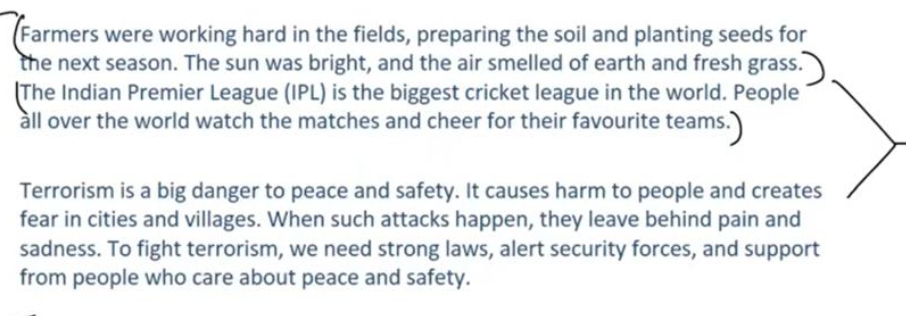

If you use recursive character text splitter and you set decent chunk size, it breaks it into two chunks which is wrong, ideally there should be 3 chunks

Now we split the text on the basis of semantic meaning. We split on the basis of when we observe two texts have very different meaning

# Step 1: Break the documents into sentences

For example:

S1 = Farmers were working hard in the fields...

S2 = The sun was bright...

S3 = The Indian Premier League is the biggest cricket league...

S4 = People all over the world watch the matches.

So instead of immediately creating chunks, we first have: S1   S2   S3   S4   S5   ...   Sn

Each sentence is treated as a small unit.


# Step 2 — Generate embeddings for every sentence

Now we use an embedding model.

For example:

S1 → [0.21, 0.73, 0.14, ...]

S2 → [0.19, 0.69, 0.17, ...]

S3 → [0.81, 0.12, 0.54, ...]

S4 → [0.79, 0.15, 0.51, ...]

These are called sentence embeddings. 

Idea: Similar meanings → similar vectors.



For example:

S1: Farmers are working in the field.

S2: The sun is shining over the farmland.

These sentences are related to agriculture/farming, so their embeddings should be relatively close.

Whereas:

S3: IPL is a popular cricket league.

is about cricket, so its embedding should be farther away from S1 and S2.

## Step 3 — Compare consecutive sentences

Find cosine similarity between consecutive pair of sentences.

So we calculate:

Similarity(S1, S2)

Similarity(S2, S3)

Similarity(S3, S4)

Similarity(S4, S5)

...

Example:

S1 ───── S2  similarity = 0.90

S2 ───── S3  similarity = 0.20

S3 ───── S4  similarity = 0.88


Notice what happened.

S1 → S2 = HIGH similarity. S2 → S3 = LOW similarity. S3 → S4 = HIGH similarity

This tells us that:

S1 and S2 → same topic

S2 and S3 → topic changed

S3 and S4 → same topic


## Step 4: LOW similarity = BREAKPOINT



In [ ]:
# # Suppose we have:

# S1   S2   S3   S4   S5   S6
#      ↓
# similarity scores

# 0.85  0.88  0.22  0.90  0.87
#              ↑
#          LOW similarity


# The low similarity between:

# S3 and S4

# suggests that the topic changes around this location.

# Therefore:

# Chunk 1:
# S1 + S2 + S3


# ---------------- BREAKPOINT ----------------


# Chunk 2:
# S4 + S5 + S6

So semantic chunking is essentially trying to answer:

"Where does the meaning of the document change significantly?"

## Sliding Window Approach:

Instead of looking at the entire document at once, we move through it sequentially.

In [ ]:
# S1 S2 S3 S4 S5 S6 S7
# │  │
# └──┘
# window 1

#    S2 S3
#    └──┘
#    window 2

#       S3 S4
#       └──┘
#       window 3

#          S4 S5
#          └──┘
#          window 4


# Idea: Move through the document and continuously look for a significant semantic change.

## How do we decide whether a similarity is "low"?

This is where your notes introduce different techniques.

We have similarity scores such as:

- 0.90
- 0.87
- 0.88
- 0.21
- 0.86
- 0.89
- 0.18
- 0.91

We need to determine: Which scores are unusually low?

There isn't necessarily one fixed value like: similarity < 0.5 → breakpoint

Instead, semantic chunking can determine breakpoints statistically.

There are 3 Approaches:

## Technique 1 — Standard Deviation

In [ ]:
# Suppose:

# Similarity:


# 0.90
# 0.87
# 0.88
# 0.21
# 0.86
# 0.89
# 0.18
# 0.91

# Most values are high, but:

# 0.21
# 0.18

# are unusually low.

# We calculate the mean and standard deviation.

# Then we can identify values that are sufficiently far from the normal similarity distribution.


## Technique 2 — Percentile

Instead of calculating how many standard deviations away a value is, we can look at the distribution's percentiles.

In [ ]:
# Similarity scores:

# 0.90
# 0.88
# 0.87
# 0.86
# 0.84
# 0.82
# 0.78
# 0.25
# 0.20

We might choose a low percentile such as the: 5th percentile or another appropriate percentile.

Scores below that threshold can be considered potential breakpoints.

So conceptually:

HIGH SIMILARITY

───────────────────────────────

0.80 0.85 0.87 0.90


LOW SIMILARITY

───────

0.20 0.25 <- Break Points

## Technique 3 — Interquartile Range (IQR)

IQR is commonly used for detecting values that are unusually far from the central distribution.

We calculate:

IQR = Q3 - Q1

where:

Q1 = 25th percentile

Q3 = 75th percentile

Then we can identify unusually low values using an appropriate lower-bound rule.

For example:

Lower bound = Q1 - 1.5 × IQR

Values below that boundary can be treated as outliers (Breakpoints)

## Technique 4 - Gradients

The basic idea is to look at how quickly the similarity score changes.

Suppose:

0.90 → 0.88 → 0.87 → 0.30

There is a large drop: 0.87 → 0.30 hat sharp change can indicate a topic transition.

In [ ]:
# Graphically:

# Similarity
#    |
# 1.0| ●
#    |   ●
# 0.8|      ●
#    |
# 0.6|
#    |
# 0.4|
#    |          ●
# 0.2|
#    +----------------
#        sentences

# The steep drop is a potential breakpoint.

In [ ]:
#              DOCUMENT
#                  ↓
#         Split into sentences
#                  ↓
#         S1 S2 S3 S4 S5 S6 ...
#                  ↓
#         Generate embeddings
#                  ↓
#     E1 E2 E3 E4 E5 E6 ...
#                  ↓
#  Compare consecutive embeddings
#                  ↓
#        Calculate cosine similarity
#                  ↓
#      Similarity scores generated
#                  ↓
#  Identify unusually LOW similarity
#                  ↓
#           Find BREAKPOINTS
#                  ↓
#       Split document at breakpoints
#                  ↓
#         Meaningful semantic chunks

In [30]:
%pip install -U langchain-experimental

Note: you may need to restart the kernel to use updated packages.


In [32]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_experimental.text_splitter import SemanticChunker
embedding_model=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

## breakpoint_threshold_type = 'gradient' or 'quartile' or 'percentile' or 'standard_deviation' 
splitter=SemanticChunker(embedding_model, breakpoint_threshold_type='standard_deviation',breakpoint_threshold_amount=1)

text='''
What is Pokémon?
Pokémon (short for Pocket Monsters) is a globally renowned media franchise centered on fictional creatures with unique powers, abilities, and designs. Created by Satoshi Tajiri and Ken Sugimori, the franchise debuted in 1996 with the release of the Pokémon Red and Blue video games for the Nintendo Game Boy.

Today, Pokémon spans video games, trading card games (TCG), animated television series, movies, merchandise, and competitive esports, making it one of the highest-grossing media franchises of all time.

Core Concept and Gameplay
The central premise of the Pokémon universe revolves around humans—known as Pokémon Trainers—who catch, train, and battle creatures called Pokémon.

The Goal: Trainers typically aim to catch a wide variety of species to complete the Pokédex (an electronic encyclopedia) and train a team of Pokémon to battle other trainers, ultimately striving to become a Pokémon Champion.

Turn-Based Combat: Battles are strategic and turn-based. Pokémon use up to four moves in battle, spanning various types (such as Water, Fire, Grass, Electric, Psychic, and Dragon).

The Type Advantage System: Combat heavily relies on elemental matchups. For example, Water-type moves are super-effective against Fire-type Pokémon, but less effective against Grass-type Pokémon.

Key Elements of the Franchise
1. Pokémon Evolution
Many Pokémon can evolve into new, more powerful species when they reach a specific level, are exposed to special items (like stones), experience friendship milestones, or meet other unique conditions. Evolution typically alters a Pokémon's appearance, stats, and typing.

2. Types
There are currently 18 distinct elemental types in the Pokémon universe. Every Pokémon and move possesses one or two types, which dictate their strengths and weaknesses:

Normal, Fire, Water, Grass, Electric, Ice

Fighting, Poison, Ground, Flying, Psychic, Bug

Rock, Ghost, Dragon, Dark, Steel, Fairy

3. Legendary and Mythical Pokémon
Beyond standard wild Pokémon, the universe features rare, immensely powerful creatures known as Legendary and Mythical Pokémon. These creatures often play crucial roles in the lore and mythology of the various regions and are typically difficult to find or capture.

Major Media Pillars
Video Games: Divided into "generations," the core RPG series introduces new regions, characters, and hundreds of new Pokémon species with every major installment.

Trading Card Game (TCG): A massive competitive and collecting hobby where players build decks of cards featuring Pokémon, Trainers, and Energy to defeat opponents.

Anime Series: Follows various protagonists—most famously Ash Ketchum through his multi-decade journey, followed by newer heroes like Liko and Roy—as they travel the world, make friends, and battle gym leaders.

Competitive Esports (VGC & TCG): Global circuits where players compete at regional, international, and world championship levels for prestigious titles and prizes.
'''

result=splitter.split_text(text)



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [34]:
len(result)

5

In [35]:
print(result[0])


What is Pokémon? Pokémon (short for Pocket Monsters) is a globally renowned media franchise centered on fictional creatures with unique powers, abilities, and designs. Created by Satoshi Tajiri and Ken Sugimori, the franchise debuted in 1996 with the release of the Pokémon Red and Blue video games for the Nintendo Game Boy. Today, Pokémon spans video games, trading card games (TCG), animated television series, movies, merchandise, and competitive esports, making it one of the highest-grossing media franchises of all time. Core Concept and Gameplay
The central premise of the Pokémon universe revolves around humans—known as Pokémon Trainers—who catch, train, and battle creatures called Pokémon. The Goal: Trainers typically aim to catch a wide variety of species to complete the Pokédex (an electronic encyclopedia) and train a team of Pokémon to battle other trainers, ultimately striving to become a Pokémon Champion. Turn-Based Combat: Battles are strategic and turn-based. Pokémon use up 

In [36]:
print(result[1])

2. Types
There are currently 18 distinct elemental types in the Pokémon universe. Every Pokémon and move possesses one or two types, which dictate their strengths and weaknesses:

Normal, Fire, Water, Grass, Electric, Ice

Fighting, Poison, Ground, Flying, Psychic, Bug

Rock, Ghost, Dragon, Dark, Steel, Fairy

3. Legendary and Mythical Pokémon
Beyond standard wild Pokémon, the universe features rare, immensely powerful creatures known as Legendary and Mythical Pokémon.


In [37]:
print(result[2])

These creatures often play crucial roles in the lore and mythology of the various regions and are typically difficult to find or capture.
